# 🧩 Tutorial – Clasificación de Imágenes de Flores con Redes Neuronales Convolucionales (CNN)

## 🎯 Objetivo

Entrenar un modelo de red neuronal convolucional (CNN) utilizando imágenes reales de flores para clasificar correctamente entre cinco especies: **rosas**, **tulipanes**, **girasoles**, **margaritas** y **dientes de león**.

Este ejercicio tiene como propósito:

- Comprender cómo procesar imágenes con TensorFlow.
- Construir una CNN básica para clasificación multiclase.
- Evaluar y visualizar el rendimiento del modelo con métricas y gráficos.
- Explorar el uso de arquitecturas convolucionales para tareas reales de visión por computador.

---

## 📦 Dataset

Usaremos el conjunto de datos de flores disponible en TensorFlow, que contiene cientos de imágenes distribuidas en cinco carpetas correspondientes a las clases mencionadas. Este dataset se descargará automáticamente desde el siguiente repositorio:

📎 [`https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz`](https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz)

---

## 🛠️ Instrucciones

1. Cargar y preparar el dataset de imágenes desde el directorio.
2. Visualizar ejemplos de cada clase.
3. Construir una red neuronal convolucional básica usando Keras.
4. Entrenar el modelo y validar su rendimiento.
5. Evaluar métricas como:
   - Precisión de entrenamiento y validación
   - Gráficos de pérdida vs. época
   - Matriz de confusión (opcional)
6. Visualizar predicciones y analizar posibles errores.

---

## 🧠 Preguntas para Reflexionar

- ¿Qué tan bien se desempeñó el modelo en las clases más difíciles?
- ¿Cuál es la importancia del preprocesamiento (normalización, batching, etc.)?
- ¿Qué mejoras podrías hacerle a esta red CNN básica?
- ¿Cómo afecta el número de filtros o capas a la complejidad y precisión del modelo?

---

> **💡 Tip:** Puedes experimentar agregando técnicas como `Dropout`, `Data Augmentation`, o probar arquitecturas más profundas como `Xception` o `MobileNet`.





228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Found 3670 files belonging to 1 classes.
Using 2936 files for training.
Found 3670 files belonging to 1 classes.
Using 734 files for validation.
Clases: ['flower_photos']
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accurac

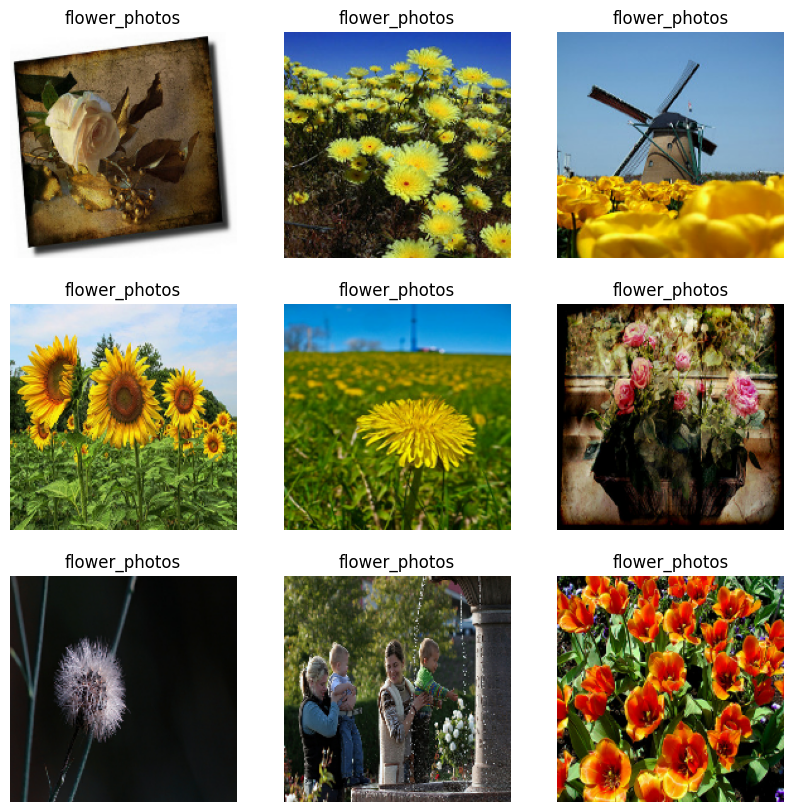

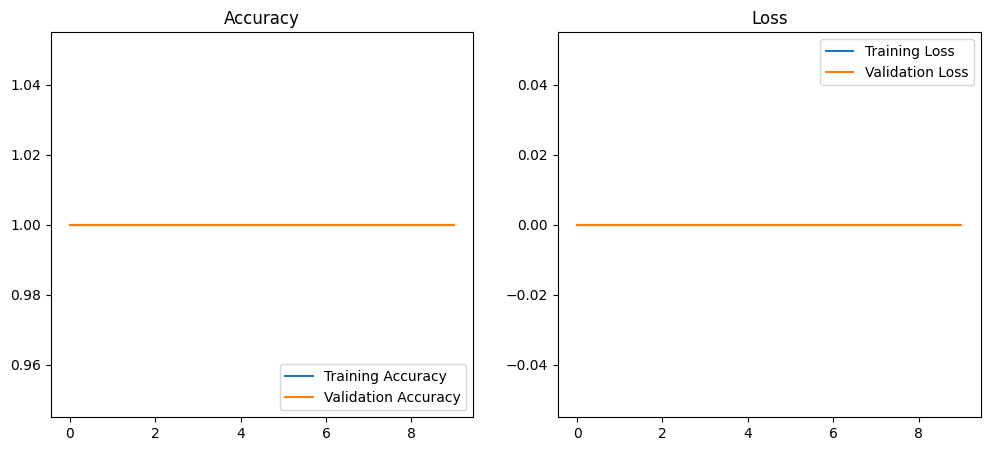

In [ ]:
# 🧠 Clasificación de Imágenes con CNN en TensorFlow

# 1. Librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 2. Cargar el dataset de flores desde TensorFlow Datasets
import pathlib

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file(origin=dataset_url, fname='flower_photos', untar=True)
data_dir = pathlib.Path(data_dir)

# 3. Configuración básica
iM_SIZE = (180, 180)
BATCH_SIZE = 32

# 4. Cargar y preprocesar datos
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=iM_SIZE,
  batch_size=BATCH_SIZE)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=iM_SIZE,
  batch_size=BATCH_SIZE)

# 5. Clases
class_names = train_ds.class_names
print("Clases:", class_names)

# 6. Visualizar algunas imágenes
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

# 7. Configurar para rendimiento
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 8. Normalización
normalization_layer = layers.Rescaling(1./255)

# 9. Modelo CNN básico
model = keras.Sequential([
  layers.Rescaling(1./255, input_shape=(180, 180, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(len(class_names))
])

# 10. Compilar modelo
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# 11. Entrenar modelo
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=10
)

# 12. Visualizar resultados
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(10)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Loss')
plt.show()


## 🖼️ Visualización del Dataset de Flores

 Para entrenar cualquier modelo de clasificación de imágenes, es fundamental **familiarizarse con los datos**. En este conjunto de datos, las imágenes corresponden a distintas especies de flores, incluyendo:

- Diente de león (`dandelion`)
- Margarita (`daisy`)
- Rosa (`roses`)
- Girasol (`sunflowers`)
- Tulipán (`tulips`)

Estas imágenes fueron descargadas automáticamente desde el repositorio oficial de TensorFlow y divididas en conjuntos de entrenamiento y validación.


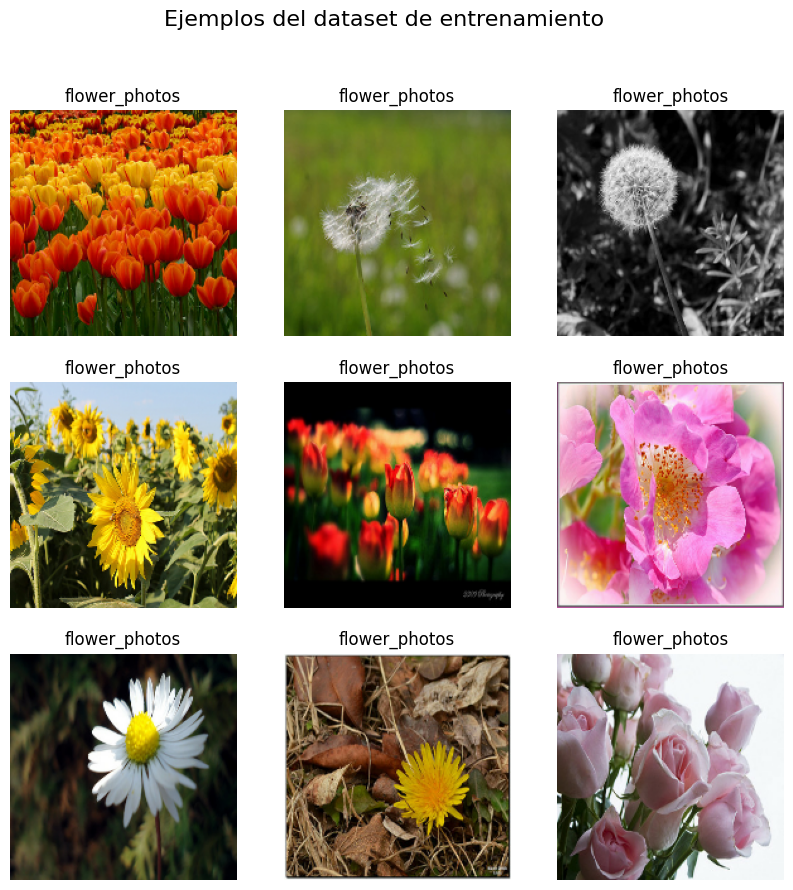

In [ ]:
# 🔍 Visualización de imágenes desde el dataset de entrenamiento

import matplotlib.pyplot as plt

# Tomar un batch del dataset
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.suptitle("Ejemplos del dataset de entrenamiento", fontsize=16)
plt.show()
